# Visibility Design and Breakthrough Discovery

This notebook creates a stylized three-panel distribution figure and three standalone panels. The dashed curve is the common independent parallel-search baseline; the solid curve represents search with visibility.

The notebook is compatible with both NumPy 1.x and 2.x.

## Goal

Illustrate why visibility can concentrate solution outcomes without uniquely determining breakthrough likelihood. Depending on where the narrower distribution is located, visibility may reduce, preserve, or increase the mass beyond a common breakthrough threshold.

## Setup

Only NumPy and Matplotlib are required. By default, exported figures are written to the notebook's current working directory. Change `OUTPUT_DIR` if you prefer a dedicated figure folder.

In [23]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np

# Notebook-safe replacement for Path(__file__).resolve().parent.
OUTPUT_DIR = Path.cwd()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"NumPy version: {np.__version__}")
print(f"Figure output directory: {OUTPUT_DIR.resolve()}")

NumPy version: 1.26.4
Figure output directory: /Users/junyi/Documents/GitHub/OpenInnovationFramework/ISR/illustrations


## Parameters

The means, standard deviations, threshold, labels, and colors are grouped here for easy revision.

In [24]:
# Stylized, normalized solution-quality axis.
X = np.linspace(0.001, 0.999, 1600)
BREAKTHROUGH_THRESHOLD = 0.82

# Common independent-search baseline.
BASELINE_MEAN = 0.60
BASELINE_SD = 0.17

# Each visibility condition is narrower than the baseline.
CONDITIONS = [
    {
        "panel": "a",
        "title": "(a) Visibility Designs Hinder\nBreakthrough Discovery",
        "mean": 0.62,
        "sd": 0.085,
        "effect": "Narrower distribution\nSmaller breakthrough tail",
    },
    {
        "panel": "b",
        "title": "(b) Visibility Designs Have Negligible Impact on\nBreakthrough Discovery",
        "mean": 0.706,
        "sd": 0.085,
        "effect": "Narrower distribution\nSimilar breakthrough tail",
    },
    {
        "panel": "c",
        "title": "(c) Visibility Designs Enhance\nBreakthrough Discovery",
        "mean": 0.755,
        "sd": 0.075,
        "effect": "Narrower distribution\nLarger breakthrough tail",
    },
]

BASELINE_COLOR = "#777777"
VISIBILITY_COLOR = "#123B63"
THRESHOLD_COLOR = "#A14A3C"

## Compatibility and density construction

`numpy.trapezoid` was introduced in NumPy 2.0. The compatibility helper below uses it when available and otherwise falls back to `numpy.trapz`, which is available in NumPy 1.x.

In [25]:
def trapezoidal_integral(y, x):
    """Integrate y over x under both NumPy 1.x and NumPy 2.x."""
    trapezoid = getattr(np, "trapezoid", None)
    if trapezoid is not None:
        return trapezoid(y, x)
    return np.trapz(y, x)


def truncated_normal_density(x, mean, sd):
    """Return a normal density renormalized over the displayed interval."""
    density = np.exp(-0.5 * ((x - mean) / sd) ** 2) / (
        sd * math.sqrt(2 * math.pi)
    )
    normalizing_constant = trapezoidal_integral(density, x)
    if not np.isfinite(normalizing_constant) or normalizing_constant <= 0:
        raise ValueError("Density could not be normalized. Check mean, sd, and X.")
    return density / normalizing_constant


BASELINE = truncated_normal_density(X, BASELINE_MEAN, BASELINE_SD)
np.testing.assert_allclose(
    trapezoidal_integral(BASELINE, X), 1.0, rtol=1e-6, atol=1e-8
)

integration_function = (
    "numpy.trapezoid" if hasattr(np, "trapezoid") else "numpy.trapz"
)
print(f"Density normalization check passed using {integration_function}.")

Density normalization check passed using numpy.trapz.


## Plotting functions

In [26]:
def configure_matplotlib():
    """Apply consistent, publication-oriented styling."""
    plt.rcParams.update(
        {
            "font.family": "DejaVu Sans",
            "axes.edgecolor": "#333333",
            "axes.linewidth": 1.1,
            "axes.titlesize": 11.7,
            "axes.labelsize": 10.4,
            "legend.fontsize": 9.0,
        }
    )


def draw_panel(ax, condition, *, show_ylabel=False, show_legend=False):
    """Draw one visibility condition against the common baseline."""
    visible = truncated_normal_density(X, condition["mean"], condition["sd"])
    tail = X >= BREAKTHROUGH_THRESHOLD

    ax.fill_between(
        X[tail], 0, BASELINE[tail],
        color=BASELINE_COLOR, alpha=0.12, linewidth=0, zorder=1,
    )
    ax.fill_between(
        X[tail], 0, visible[tail],
        color=VISIBILITY_COLOR, alpha=0.24, linewidth=0, zorder=2,
    )

    ax.plot(
        X, BASELINE,
        color=BASELINE_COLOR, linestyle=(0, (5, 3)), linewidth=2.0,
        label="Independent parallel search", zorder=3,
    )
    ax.plot(
        X, visible,
        color=VISIBILITY_COLOR, linewidth=2.4,
        label="Search with visibility", zorder=4,
    )
    ax.axvline(
        BREAKTHROUGH_THRESHOLD,
        color=THRESHOLD_COLOR, linestyle=(0, (2, 2)), linewidth=1.5, zorder=5,
    )

    ax.set_title(condition["title"], pad=13, fontweight="semibold")
    ax.set_xlabel("Solution quality (low  →  high)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 5.85)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        BREAKTHROUGH_THRESHOLD + 0.008, 5.54, "Breakthrough\nthreshold",
        color=THRESHOLD_COLOR, fontsize=8.3, ha="left", va="top",
    )
    ax.text(
        0.035, 5.40, condition["effect"],
        color=VISIBILITY_COLOR, fontsize=8.8, ha="left", va="top",
        linespacing=1.35,
    )

    if show_ylabel:
        ax.set_ylabel("Relative frequency of solutions")

    if show_legend:
        ax.legend(
            loc="upper left", bbox_to_anchor=(0.02, 0.77),
            frameon=False, handlelength=3.0,
        )


configure_matplotlib()

## Combined three-panel figure

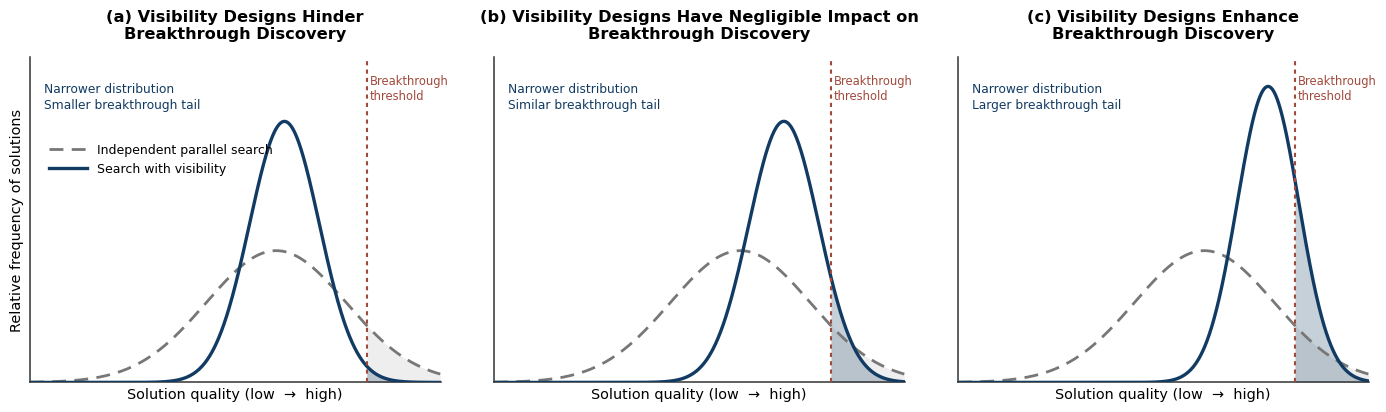

Saved: /Users/junyi/Documents/GitHub/OpenInnovationFramework/ISR/illustrations/visibility_distribution_illustration.png


In [30]:
def save_combined_figure():
    """Create, display, and export the integrated illustration."""
    fig, axes = plt.subplots(
        1, 3, figsize=(14.4, 4.8), sharex=True, sharey=True
    )
    fig.patch.set_facecolor("white")

    for index, (ax, condition) in enumerate(zip(axes, CONDITIONS)):
        draw_panel(
            ax, condition,
            show_ylabel=index == 0,
            show_legend=index == 0,
        )

    # fig.suptitle(
    #     "How Visibility Design May Affect Breakthrough Discovery",
    #     fontsize=16.2, fontweight="semibold", color="#17202A", y=1.015,
    # )
    # fig.text(
    #     0.5, 0.005,
    #     (
    #         "Stylized distributions. All visibility conditions concentrate "
    #         "search outcomes; their location determines the breakthrough tail."
    #     ),
    #     ha="center", va="bottom", fontsize=9.2, color="#4B4B4B",
    # )

    plt.tight_layout(rect=(0.015, 0.06, 0.995, 0.94), w_pad=2.2)
    output_path = OUTPUT_DIR / "visibility_distribution_illustration.png"
    fig.savefig(output_path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)
    return output_path


combined_figure_path = save_combined_figure()
print(f"Saved: {combined_figure_path.resolve()}")

## Standalone panels

Each standalone file includes its own y-axis label and legend so that it can be used independently.

In [28]:
def save_individual_panels():
    """Export each panel as a self-contained figure."""
    output_paths = []

    for condition in CONDITIONS:
        fig, ax = plt.subplots(figsize=(5.4, 4.8))
        fig.patch.set_facecolor("white")
        draw_panel(ax, condition, show_ylabel=True, show_legend=True)

        plt.tight_layout(rect=(0.02, 0.02, 0.99, 0.98))
        output_path = OUTPUT_DIR / f"visibility_panel_{condition['panel']}.png"
        fig.savefig(
            output_path, dpi=240, bbox_inches="tight", facecolor="white"
        )
        plt.close(fig)
        output_paths.append(output_path)

    return output_paths


panel_paths = save_individual_panels()
for panel_path in panel_paths:
    print(f"Saved: {panel_path.resolve()}")

Saved: /Users/junyi/Documents/GitHub/OpenInnovationFramework/ISR/illustrations/visibility_panel_a.png
Saved: /Users/junyi/Documents/GitHub/OpenInnovationFramework/ISR/illustrations/visibility_panel_b.png
Saved: /Users/junyi/Documents/GitHub/OpenInnovationFramework/ISR/illustrations/visibility_panel_c.png


## Checks

Confirm that the density functions integrate to one and that all four expected image files were generated.

In [29]:
for condition in CONDITIONS:
    density = truncated_normal_density(X, condition["mean"], condition["sd"])
    np.testing.assert_allclose(
        trapezoidal_integral(density, X), 1.0, rtol=1e-6, atol=1e-8
    )

expected_files = [combined_figure_path, *panel_paths]
missing_files = [path for path in expected_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(f"Missing expected output files: {missing_files}")

print("All density and file-generation checks passed.")
for path in expected_files:
    print(f"- {path.name}: {path.stat().st_size:,} bytes")

All density and file-generation checks passed.
- visibility_distribution_illustration.png: 268,030 bytes
- visibility_panel_a.png: 127,383 bytes
- visibility_panel_b.png: 131,977 bytes
- visibility_panel_c.png: 126,457 bytes


## Next steps

To revise the figure, edit the values in the **Parameters** cell and rerun all cells. The most consequential values are `BREAKTHROUGH_THRESHOLD`, each condition's `mean` and `sd`, and the three color constants.